# Model Validation Against Observed 2021-2025 Quebec Vehicle Adoption

This notebook brings together the three validation steps for the current replacement-dynamics workflow:

1. **Honest province-level validation** using only information available through `2020`, then forecasting `2021-2025`.
2. **Recalibrated sales-share forecasting** using the better-performing hybrid rule identified by the backtest.
3. **FSA-level aggregate validation** where FSA forecasts are aggregated back to Quebec-level truth.

The goal is to answer one practical question: **how good is the model when compared with the observed Quebec adoption data available through 2025?**

## Validation Logic

To avoid leakage, the main backtest does **not** use the external registrations data from `2021-2025` to build the forecast it is validating.

Instead, the province-level validation is split into two honest exercises:

- **Train through 2020 -> forecast 2021-2025**
- **Rolling one-step-ahead validation** for `2021`, `2022`, `2023`, `2024`, and `2025`

Three province sales-share forecasters are compared:

- `naive_last_share`: keeps the last observed share unchanged
- `share_delta`: the original delta-based share forecaster
- `hybrid_delta`: the improved category-specific rule that performed best in validation

The FSA validation is stricter than a typical local backtest because it asks whether the **aggregate of FSA forecasts** is still consistent with province-level truth.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f"{x:,.4f}")


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'validation_outputs').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate the adoption prediction model project root.')

PROJECT_DIR = find_project_root(Path.cwd().resolve())
VALIDATION_DIR = PROJECT_DIR / 'validation_outputs' / 'model_validation_2025'
RECAL_DIR = PROJECT_DIR / 'validation_outputs' / 'recalibrated_sales_share_forecast'
FSA_VALIDATION_DIR = PROJECT_DIR / 'validation_outputs' / 'fsa_model_validation_2025'

print('Project directory:', PROJECT_DIR)
print('Province validation directory:', VALIDATION_DIR)
print('Recalibration directory:', RECAL_DIR)
print('FSA validation directory:', FSA_VALIDATION_DIR)

Project directory: /Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model
Province validation directory: /Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/validation_outputs/model_validation_2025
Recalibration directory: /Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/validation_outputs/recalibrated_sales_share_forecast
FSA validation directory: /Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/validation_outputs/fsa_model_validation_2025


## Load Validation Tables

These tables were generated by the validation scripts in [`scripts/`](../scripts):

- `validate_model_vs_observed_2025.py`
- `recalibrate_sales_share_forecast.py`
- `validate_fsa_model_vs_province_truth.py`

In [2]:
overall = pd.read_csv(VALIDATION_DIR / 'validation_overall_summary.csv')
by_type = pd.read_csv(VALIDATION_DIR / 'validation_by_vehicle_type.csv')
by_year = pd.read_csv(VALIDATION_DIR / 'validation_by_year.csv')
comparison = pd.read_csv(VALIDATION_DIR / 'train2020_forecast2021_2025_comparison.csv')
pred_long = pd.read_csv(VALIDATION_DIR / 'predicted_vs_observed_sales_share_long.csv')

recal_2035 = pd.read_csv(RECAL_DIR / 'recalibrated_2035_summary.csv')
recal_forecast = pd.read_csv(RECAL_DIR / 'sales_share_forecast_comparison_2026_2035.csv')
observed_sales = pd.read_csv(RECAL_DIR / 'observed_sales_share_2017_2025.csv')

fsa_overall = pd.read_csv(FSA_VALIDATION_DIR / 'fsa_aggregate_validation_overall.csv')
fsa_by_type = pd.read_csv(FSA_VALIDATION_DIR / 'fsa_aggregate_validation_by_type.csv')
fsa_long = pd.read_csv(FSA_VALIDATION_DIR / 'fsa_aggregate_vs_province_long.csv')

print('Loaded province validation rows:', len(pred_long))
print('Loaded FSA aggregate validation rows:', len(fsa_long))

Loaded province validation rows: 150
Loaded FSA aggregate validation rows: 30


## Province-Level Validation Summary

This is the most important table because it tells us whether the sales-share forecaster is learning anything useful beyond a trivial baseline.

In [3]:
overall.sort_values(['validation', 'rmse', 'mae']).reset_index(drop=True)

,validation,model,mae,rmse,mean_error,max_abs_error,n
0,rolling_one_step,hybrid_delta,0.0109,0.0141,0.0000,0.0349,30
1,rolling_one_step,share_delta,0.0123,0.0159,-0.0000,0.0400,30
2,train_to_2020_forecast_2021_2025,hybrid_delta,0.0156,0.0198,-0.0000,0.0465,30
3,train_to_2020_forecast_2021_2025,share_delta,0.0311,0.0404,0.0000,0.0713,30
4,train_to_2020_forecast_2021_2025,naive_last_share,0.0371,0.0460,-0.0000,0.0839,30


### Readout

What we want to see here is simple:

- the model should beat `naive_last_share`
- the recalibrated `hybrid_delta` should improve on the original `share_delta`
- short-horizon errors should be lower than the multi-year `2020 -> 2025` backtest

In [4]:
province_rank = (
    overall[['validation', 'model', 'mae', 'rmse']]
    .sort_values(['validation', 'rmse', 'mae'])
    .reset_index(drop=True)
)
province_rank

,validation,model,mae,rmse
0,rolling_one_step,hybrid_delta,0.0109,0.0141
1,rolling_one_step,share_delta,0.0123,0.0159
2,train_to_2020_forecast_2021_2025,hybrid_delta,0.0156,0.0198
3,train_to_2020_forecast_2021_2025,share_delta,0.0311,0.0404
4,train_to_2020_forecast_2021_2025,naive_last_share,0.0371,0.0460


## Province-Level Validation by Vehicle Type

This table helps identify where the model is strong and where it still struggles. In practice, the difficult categories are the ones whose market position changed the most after 2020.

In [5]:
by_type.sort_values(['validation', 'model', 'mae'], ascending=[True, True, False]).reset_index(drop=True)

,validation,model,vehicle_type,mae,rmse,mean_error,max_abs_error,n
0,rolling_one_step,hybrid_delta,ice_van/pickup,0.0166,0.0197,0.0025,0.0349,5
1,rolling_one_step,hybrid_delta,ice_suv,0.0157,0.0169,-0.0072,0.0266,5
2,rolling_one_step,hybrid_delta,hev_suv,0.0129,0.0145,0.0012,0.0242,5
3,rolling_one_step,hybrid_delta,electric,0.0113,0.0155,0.0021,0.0291,5
4,rolling_one_step,hybrid_delta,ice_sedan,0.0063,0.0080,0.0032,0.0132,5
5,rolling_one_step,hybrid_delta,hev_sedan,0.0029,0.0029,-0.0019,0.0041,5
6,rolling_one_step,share_delta,ice_van/pickup,0.0183,0.0218,0.0106,0.0400,5
7,rolling_one_step,share_delta,electric,0.0165,0.0179,-0.0124,0.0271,5
8,rolling_one_step,share_delta,ice_suv,0.0155,0.0180,0.0083,0.0252,5
9,rolling_one_step,share_delta,hev_suv,0.0123,0.0168,-0.0123,0.0334,5


## Province-Level Validation by Forecast Year

This table shows how forecast accuracy changes with horizon length. The `train through 2020 -> forecast 2021-2025` block is especially useful because it mimics the real problem: making a multi-year forecast before the post-2020 transition fully unfolds.

In [6]:
by_year.sort_values(['validation', 'model', 'year']).reset_index(drop=True)

,validation,model,year,mae,rmse,mean_error,max_abs_error,n
0,rolling_one_step,hybrid_delta,2021,0.0117,0.0181,0.0000,0.0349,6
1,rolling_one_step,hybrid_delta,2022,0.0126,0.0138,0.0000,0.0199,6
2,rolling_one_step,hybrid_delta,2023,0.0089,0.0116,0.0000,0.0242,6
3,rolling_one_step,hybrid_delta,2024,0.0067,0.0077,0.0000,0.0119,6
4,rolling_one_step,hybrid_delta,2025,0.0148,0.0170,0.0000,0.0291,6
5,rolling_one_step,share_delta,2021,0.0144,0.0192,-0.0000,0.0400,6
6,rolling_one_step,share_delta,2022,0.0147,0.0174,-0.0000,0.0271,6
7,rolling_one_step,share_delta,2023,0.0169,0.0196,-0.0000,0.0334,6
8,rolling_one_step,share_delta,2024,0.0115,0.0134,0.0000,0.0214,6
9,rolling_one_step,share_delta,2025,0.0039,0.0051,-0.0000,0.0103,6


## Province Validation Plots

observed_vs_predicted_sales_share_by_type.png


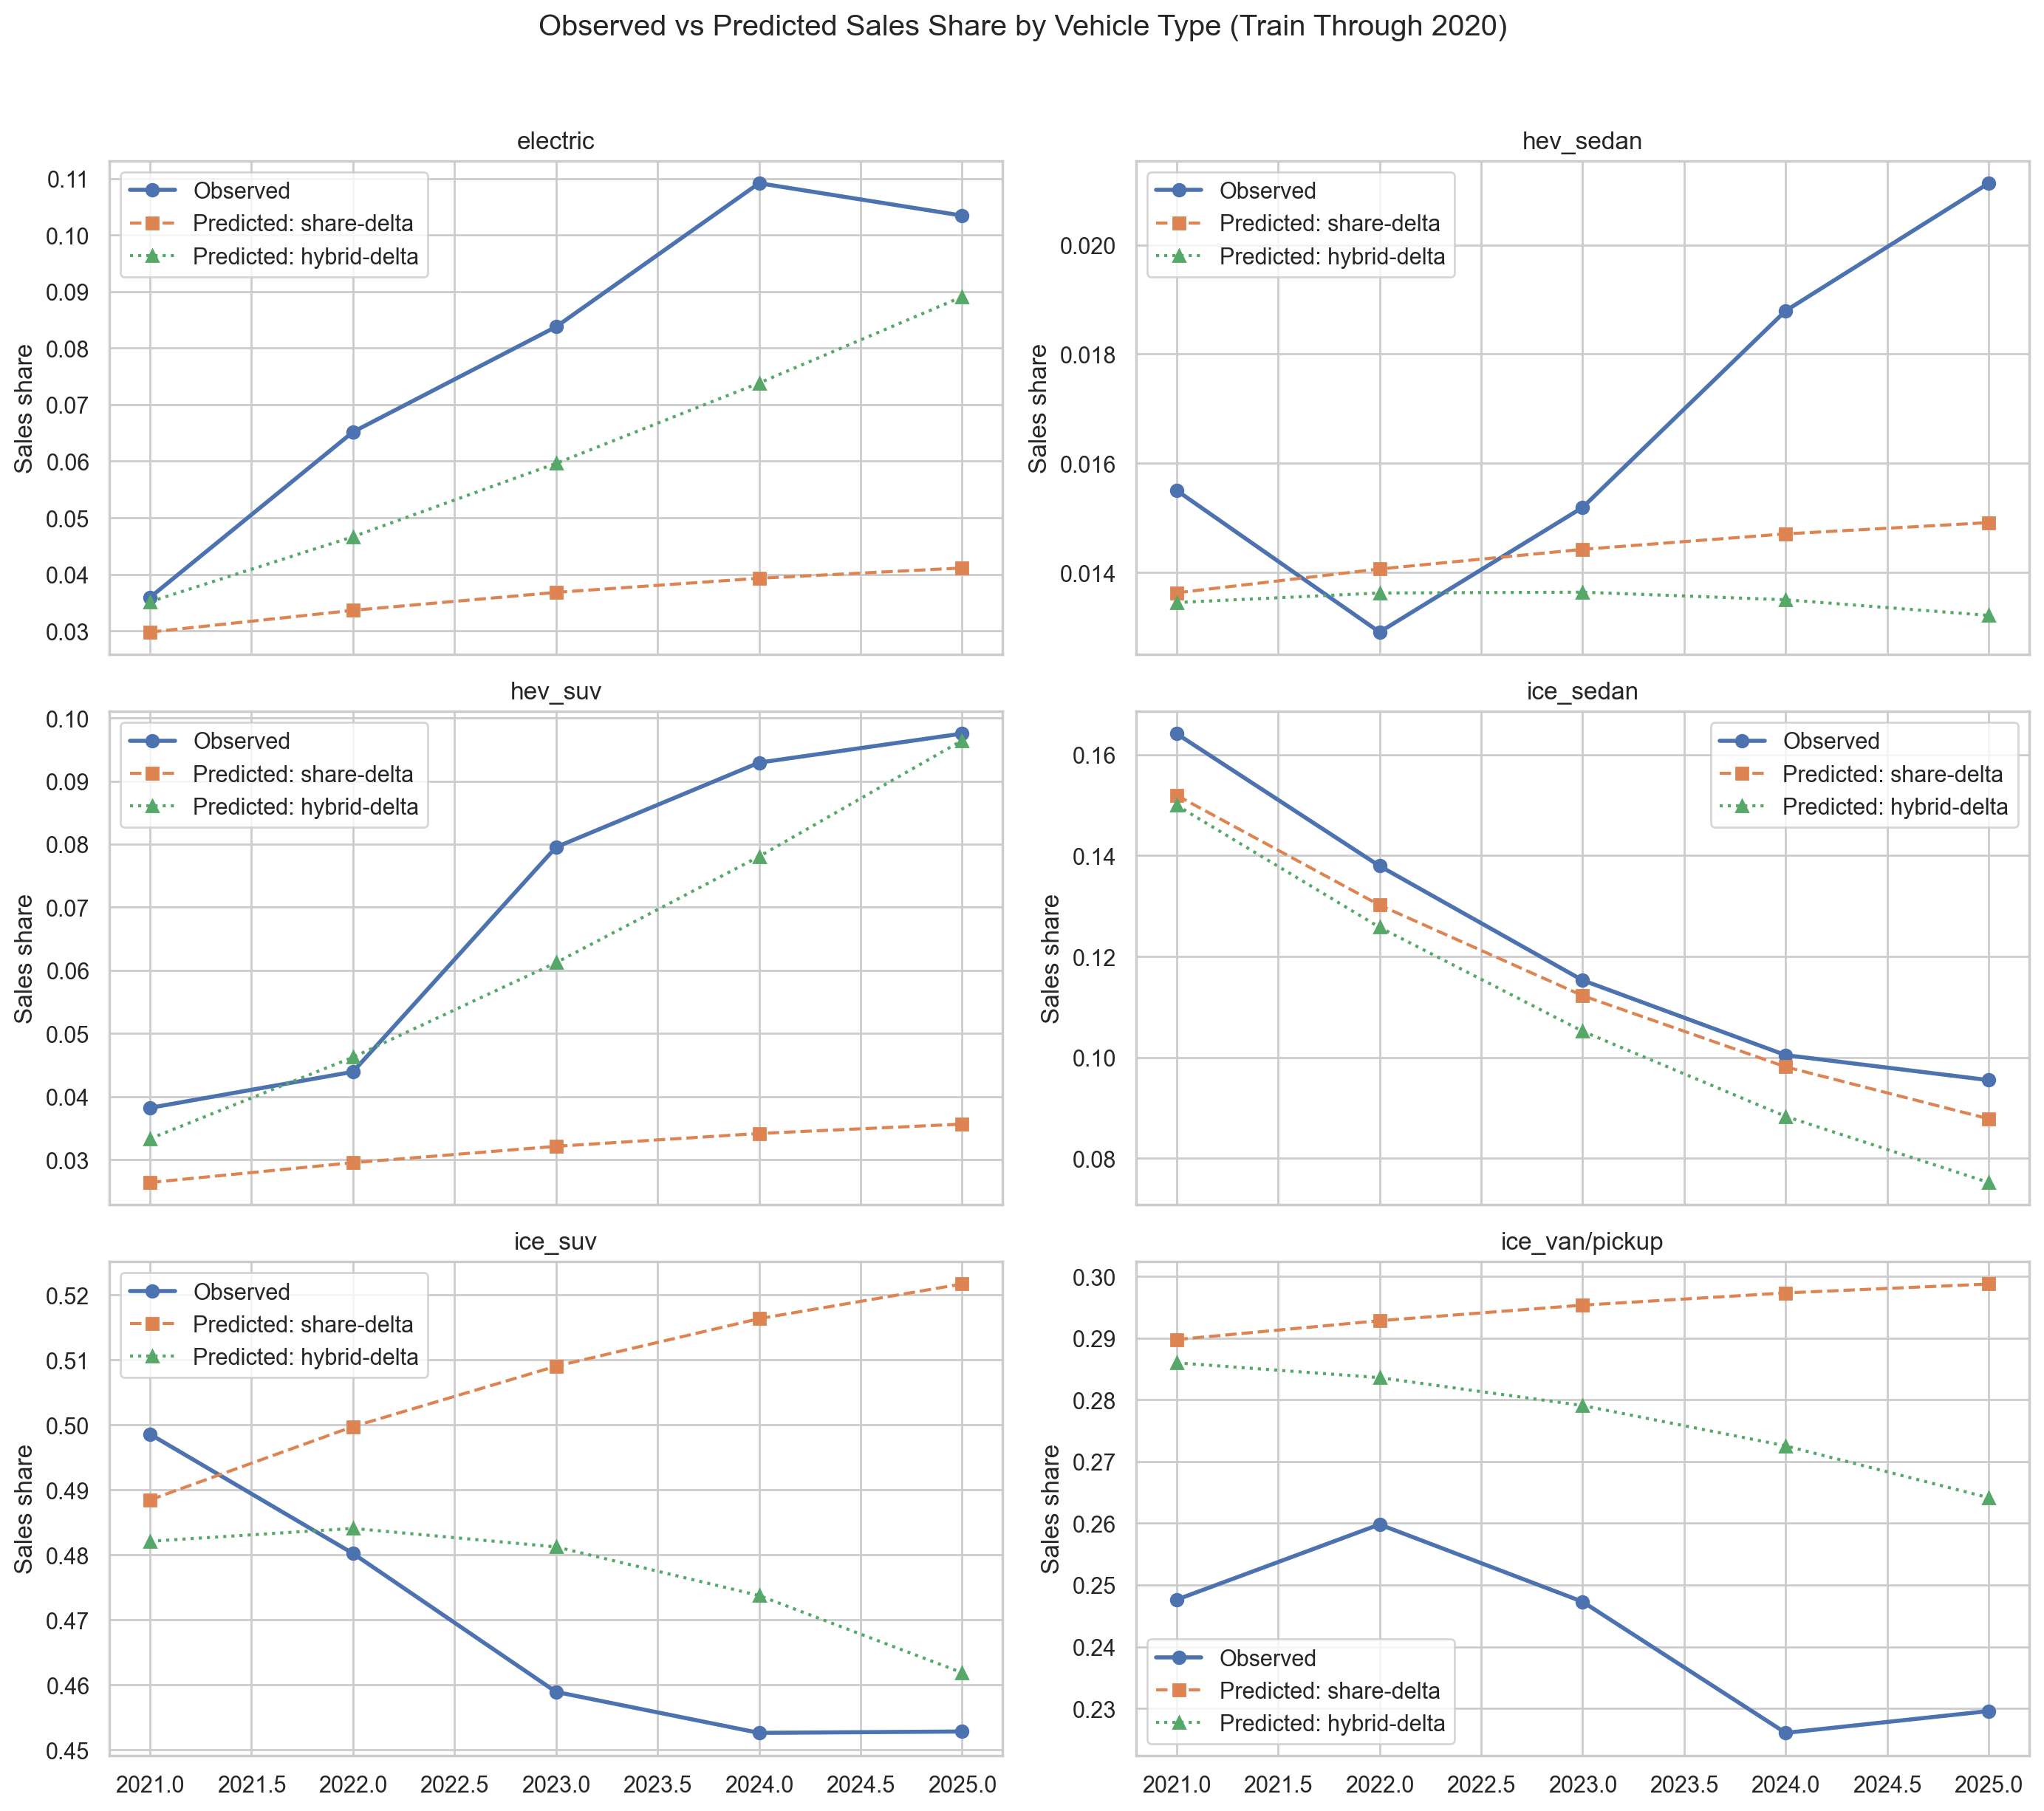

ev_sales_share_backtest.png


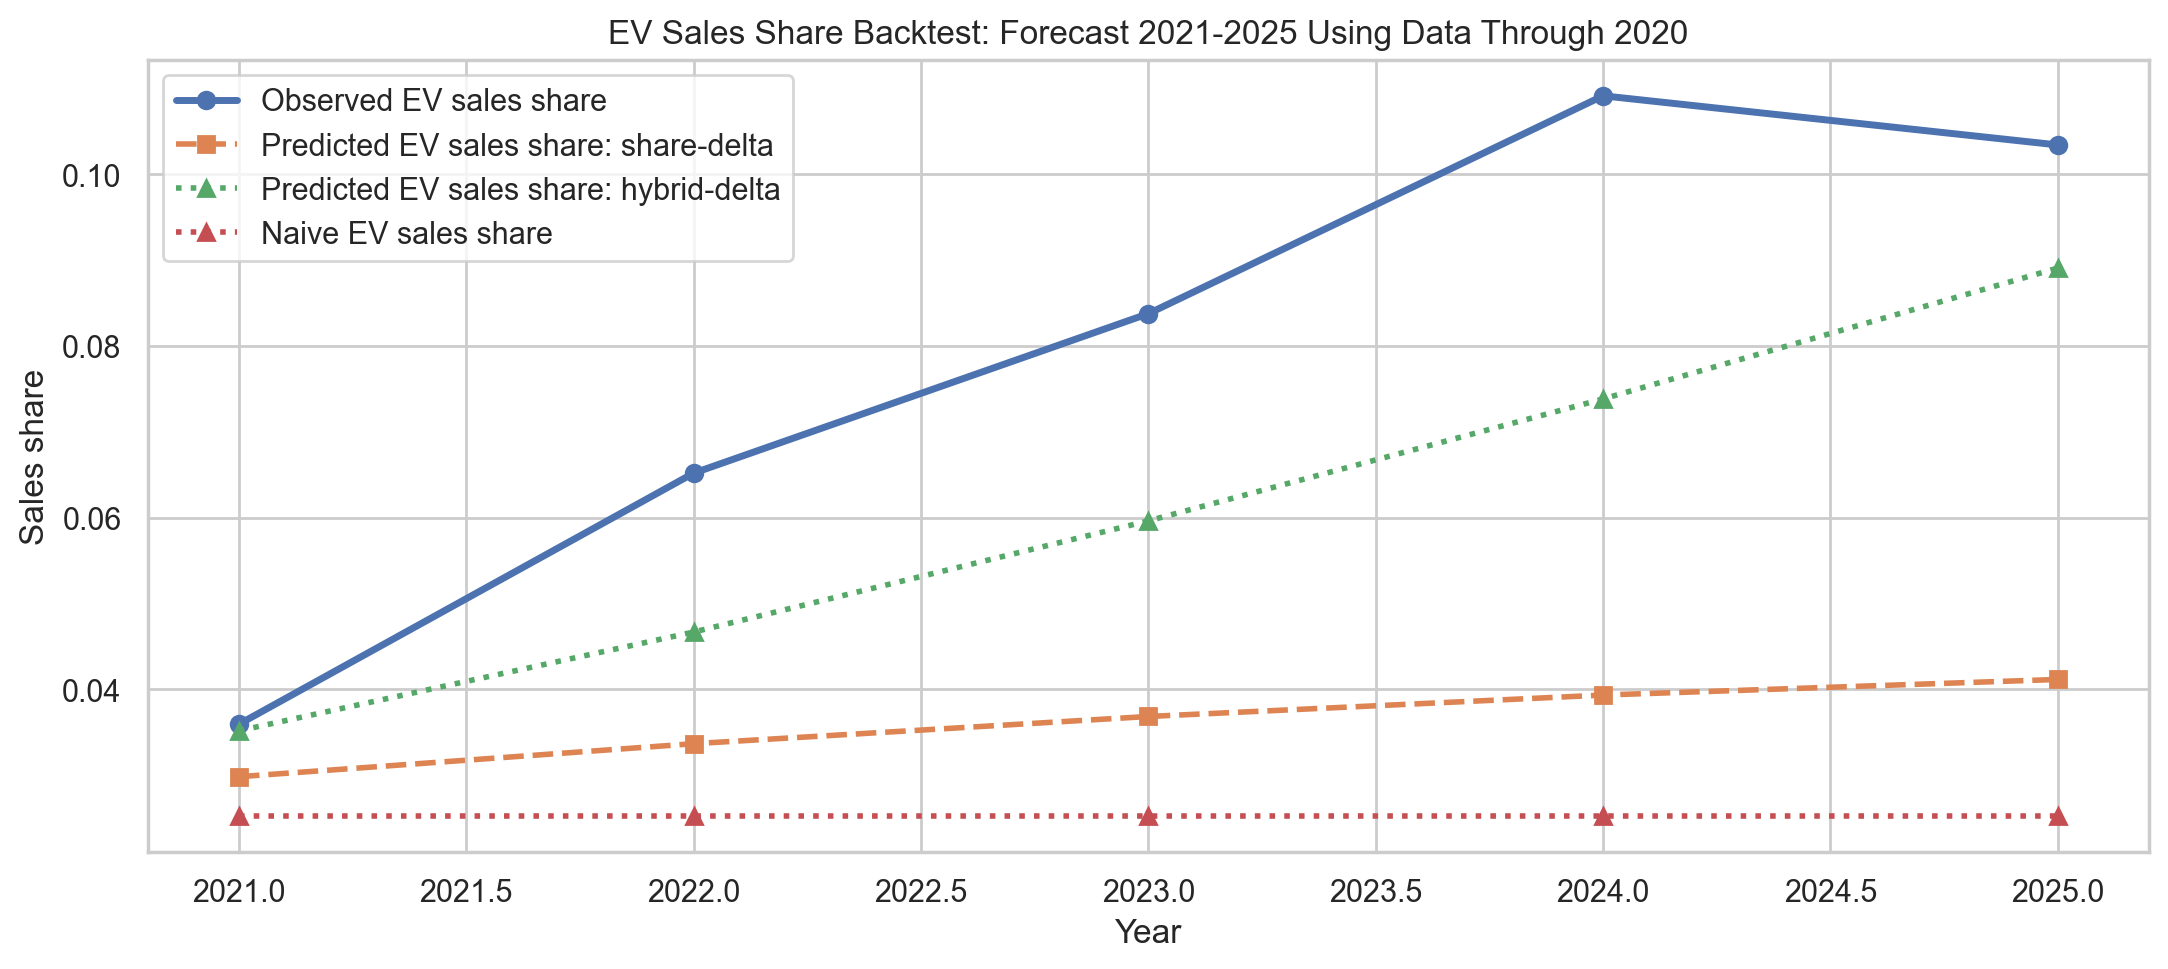

mae_by_vehicle_type.png


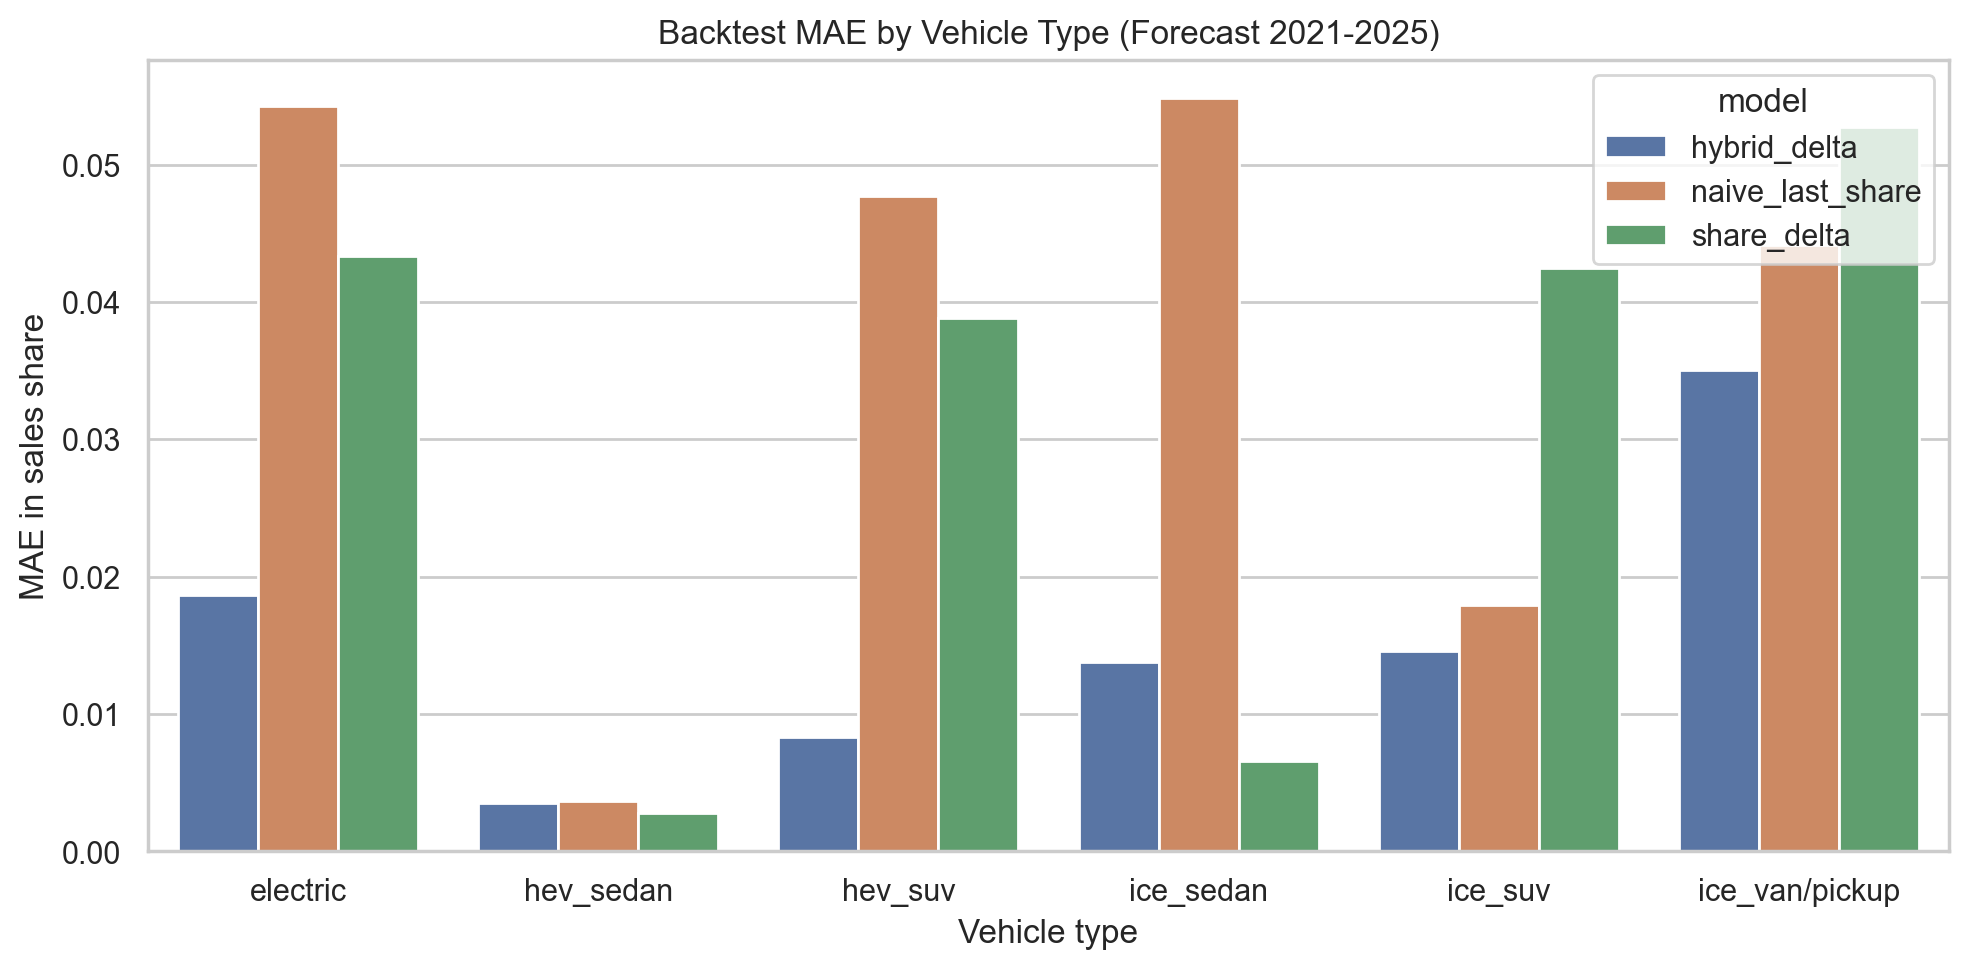

mae_by_year.png


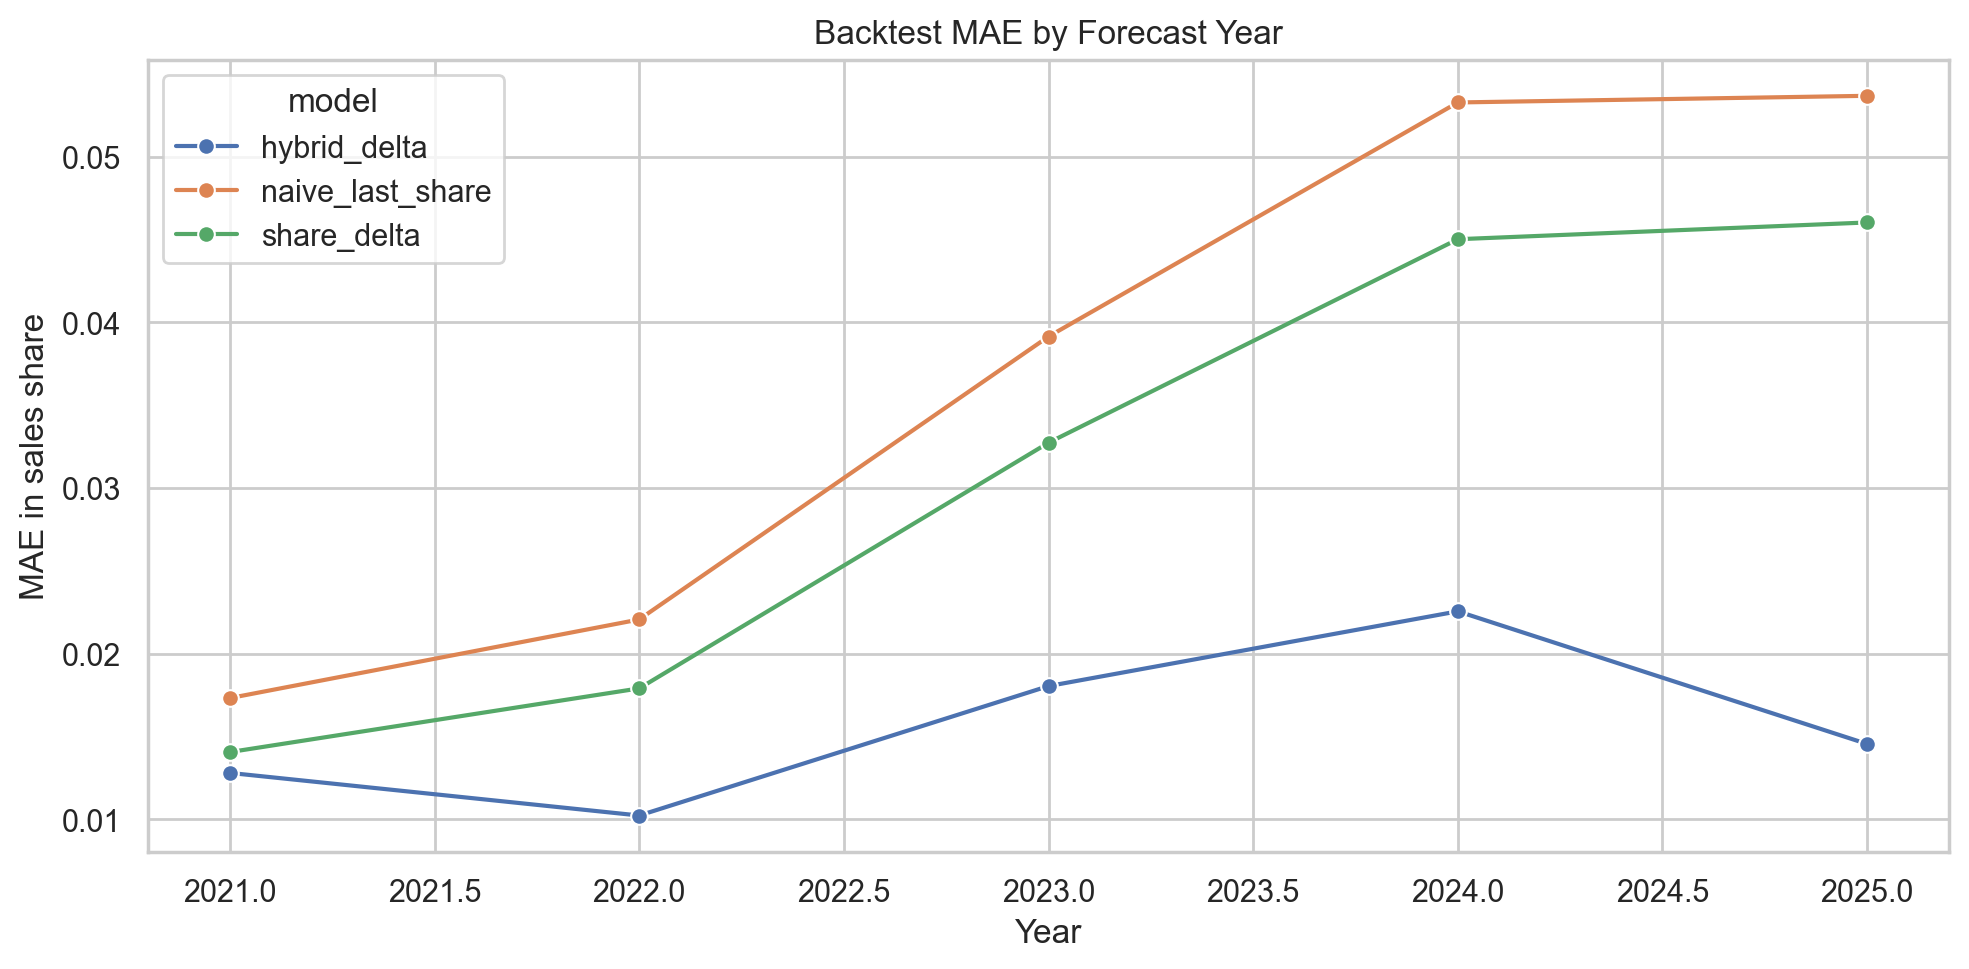

In [7]:
for name in [
    'observed_vs_predicted_sales_share_by_type.png',
    'ev_sales_share_backtest.png',
    'mae_by_vehicle_type.png',
    'mae_by_year.png',
]:
    print(name)
    display(Image(filename=str(VALIDATION_DIR / name)))

## What Changed in the Recalibration

The original `share_delta` rule was too aggressive for some categories and did not track the post-2020 transition well enough.

The improved rule is a **hybrid**:

- `electric` and `hev_suv` keep a linear delta trend
- the remaining categories use a damped average-delta logic

This hybrid rule was selected because it improved out-of-sample fit from `2021-2025`.

In [8]:
recal_2035 = recal_2035.rename(columns={'Unnamed: 0': 'vehicle_type'})
recal_2035.sort_values('difference')

,vehicle_type,baseline_2035,recalibrated_2035,difference
0,electric,0.1902,0.1111,-0.0792
4,ice_suv,0.3940,0.3547,-0.0394
5,ice_van/pickup,0.2064,0.1859,-0.0205
3,ice_sedan,0.0073,0.0047,-0.0026
1,hev_sedan,0.0284,0.0258,-0.0026
2,hev_suv,0.1737,0.3179,0.1442


### Interpretation of the Recalibration Table

The `difference` column is `recalibrated_2035 - baseline_2035`.

A negative value means the recalibrated model is **less aggressive** than the original baseline by 2035. This is especially important for `electric`, where the recalibrated path is more conservative and better aligned with the observed `2021-2025` data.

recalibrated_sales_share_forecast.png


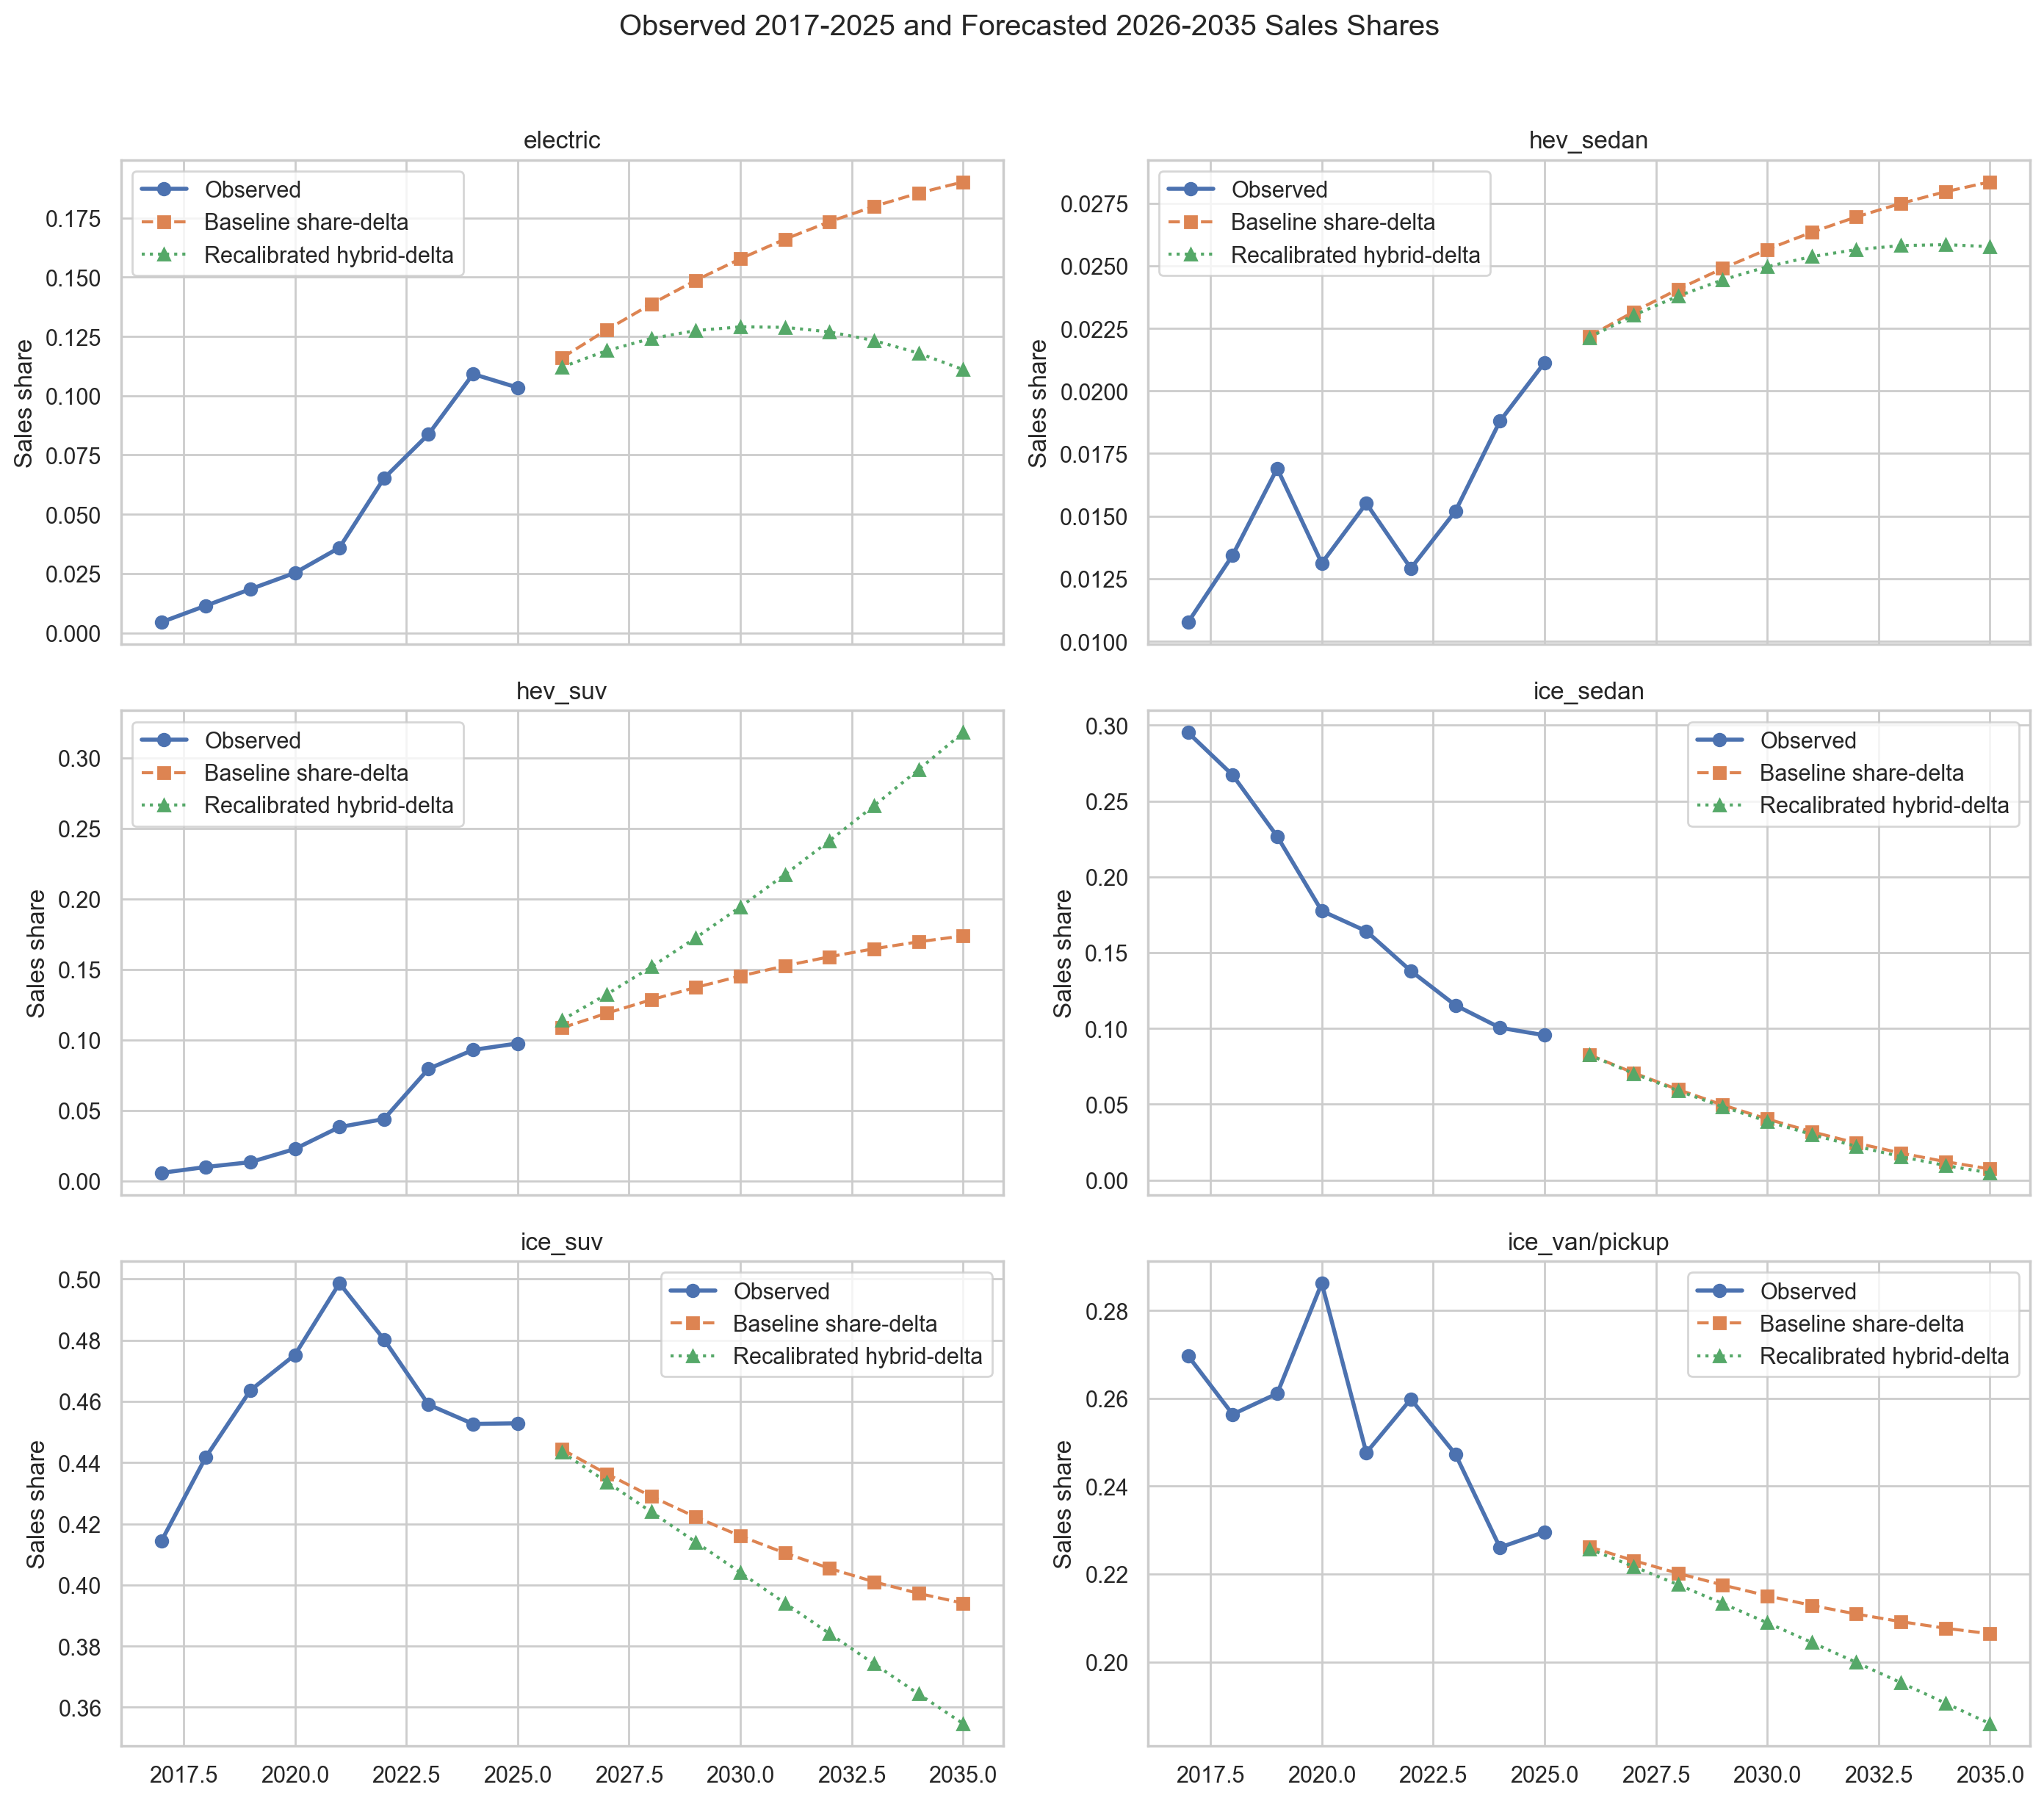

recalibrated_2035_barplot.png


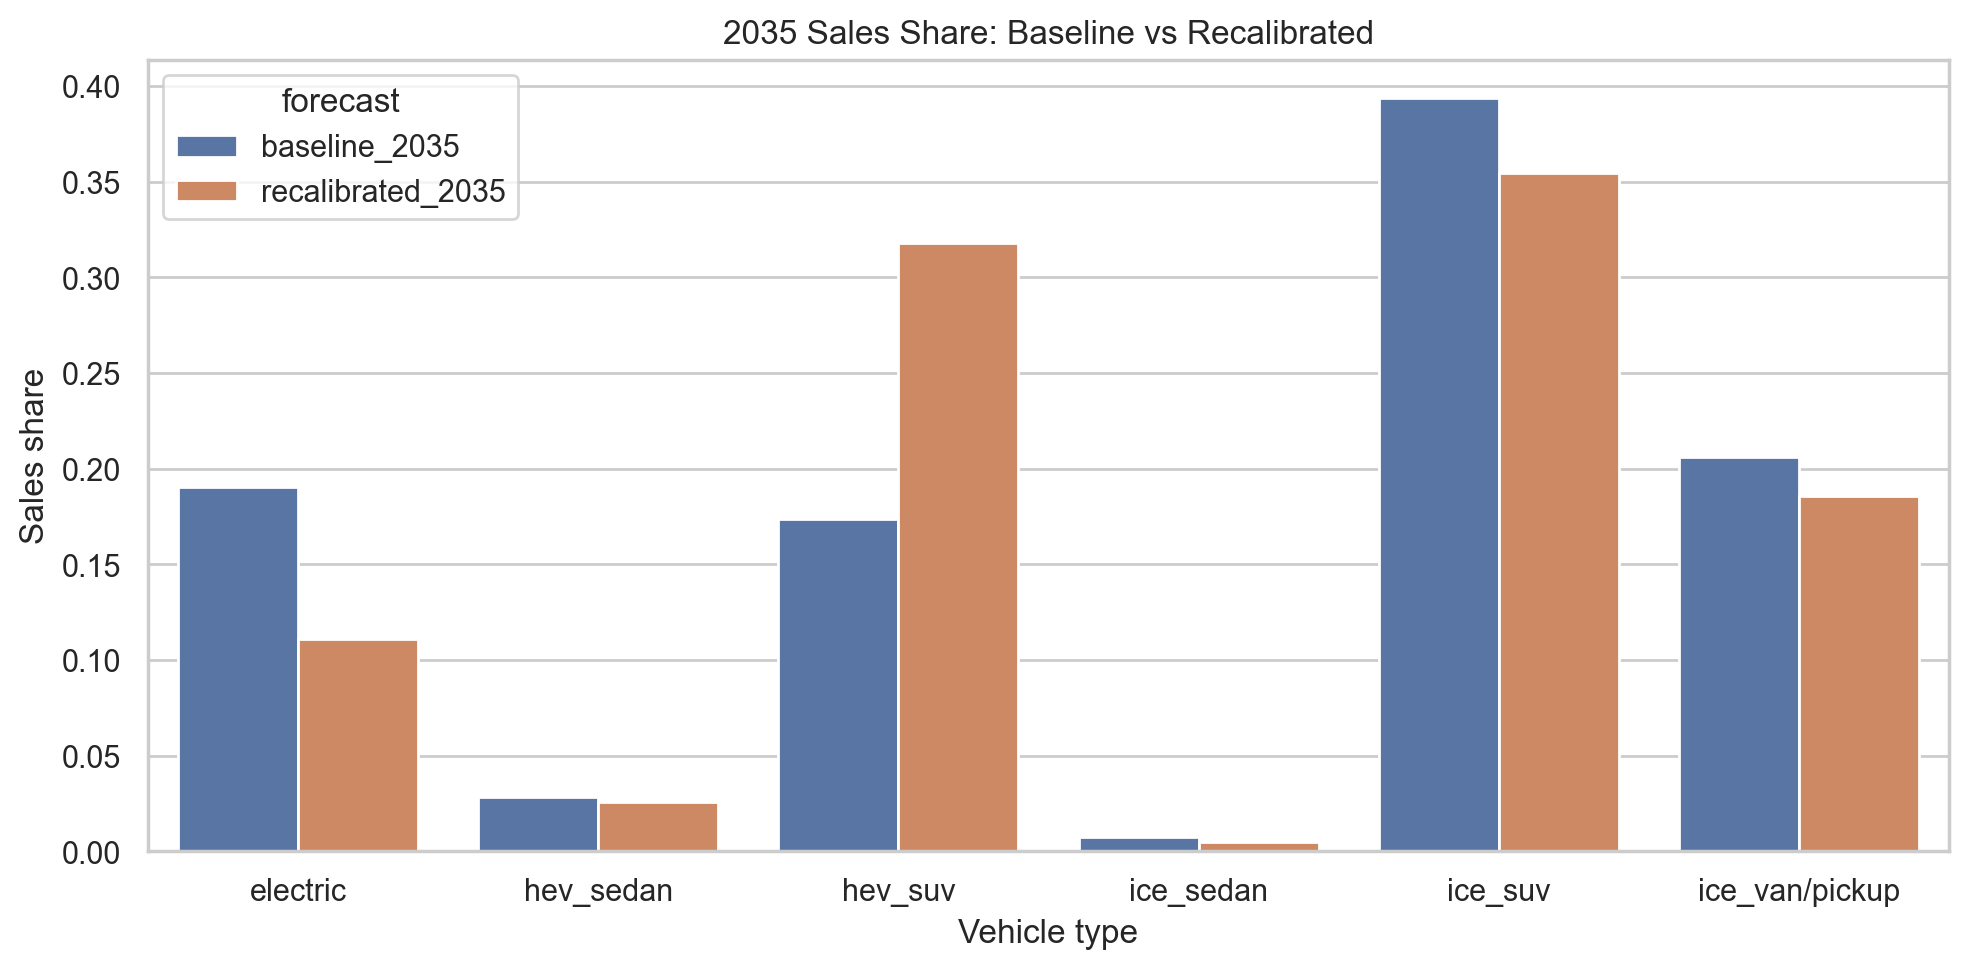

In [9]:
for name in [
    'recalibrated_sales_share_forecast.png',
    'recalibrated_2035_barplot.png',
]:
    print(name)
    display(Image(filename=str(RECAL_DIR / name)))

## FSA Validation Anchored to Province Truth

The FSA model is more ambitious: it allows local variation but shrinks sparse FSAs toward the province benchmark. The natural validation question is whether the **aggregate of all FSA forecasts** still reproduces Quebec-level reality.

This is a hard test. If the aggregate of FSA forecasts drifts away from the observed province benchmark, that means the local structure is still introducing too much noise.

In [10]:
fsa_overall

,mae,rmse,mean_error,max_abs_error
0,0.0401,0.0513,-0.0000,0.0996


In [11]:
fsa_by_type.sort_values('mae', ascending=False).reset_index(drop=True)

,vehicle_type,mae,rmse,mean_error,max_abs_error
0,ice_van/pickup,0.0835,0.0840,-0.0835,0.0984
1,ice_suv,0.0677,0.0742,0.0677,0.0996
2,ice_sedan,0.0443,0.0461,0.0443,0.0557
3,hev_suv,0.0241,0.0280,-0.0241,0.0388
4,electric,0.0153,0.0171,-0.0101,0.0295
5,hev_sedan,0.0057,0.0060,0.0057,0.0085


fsa_aggregate_vs_province_by_type.png


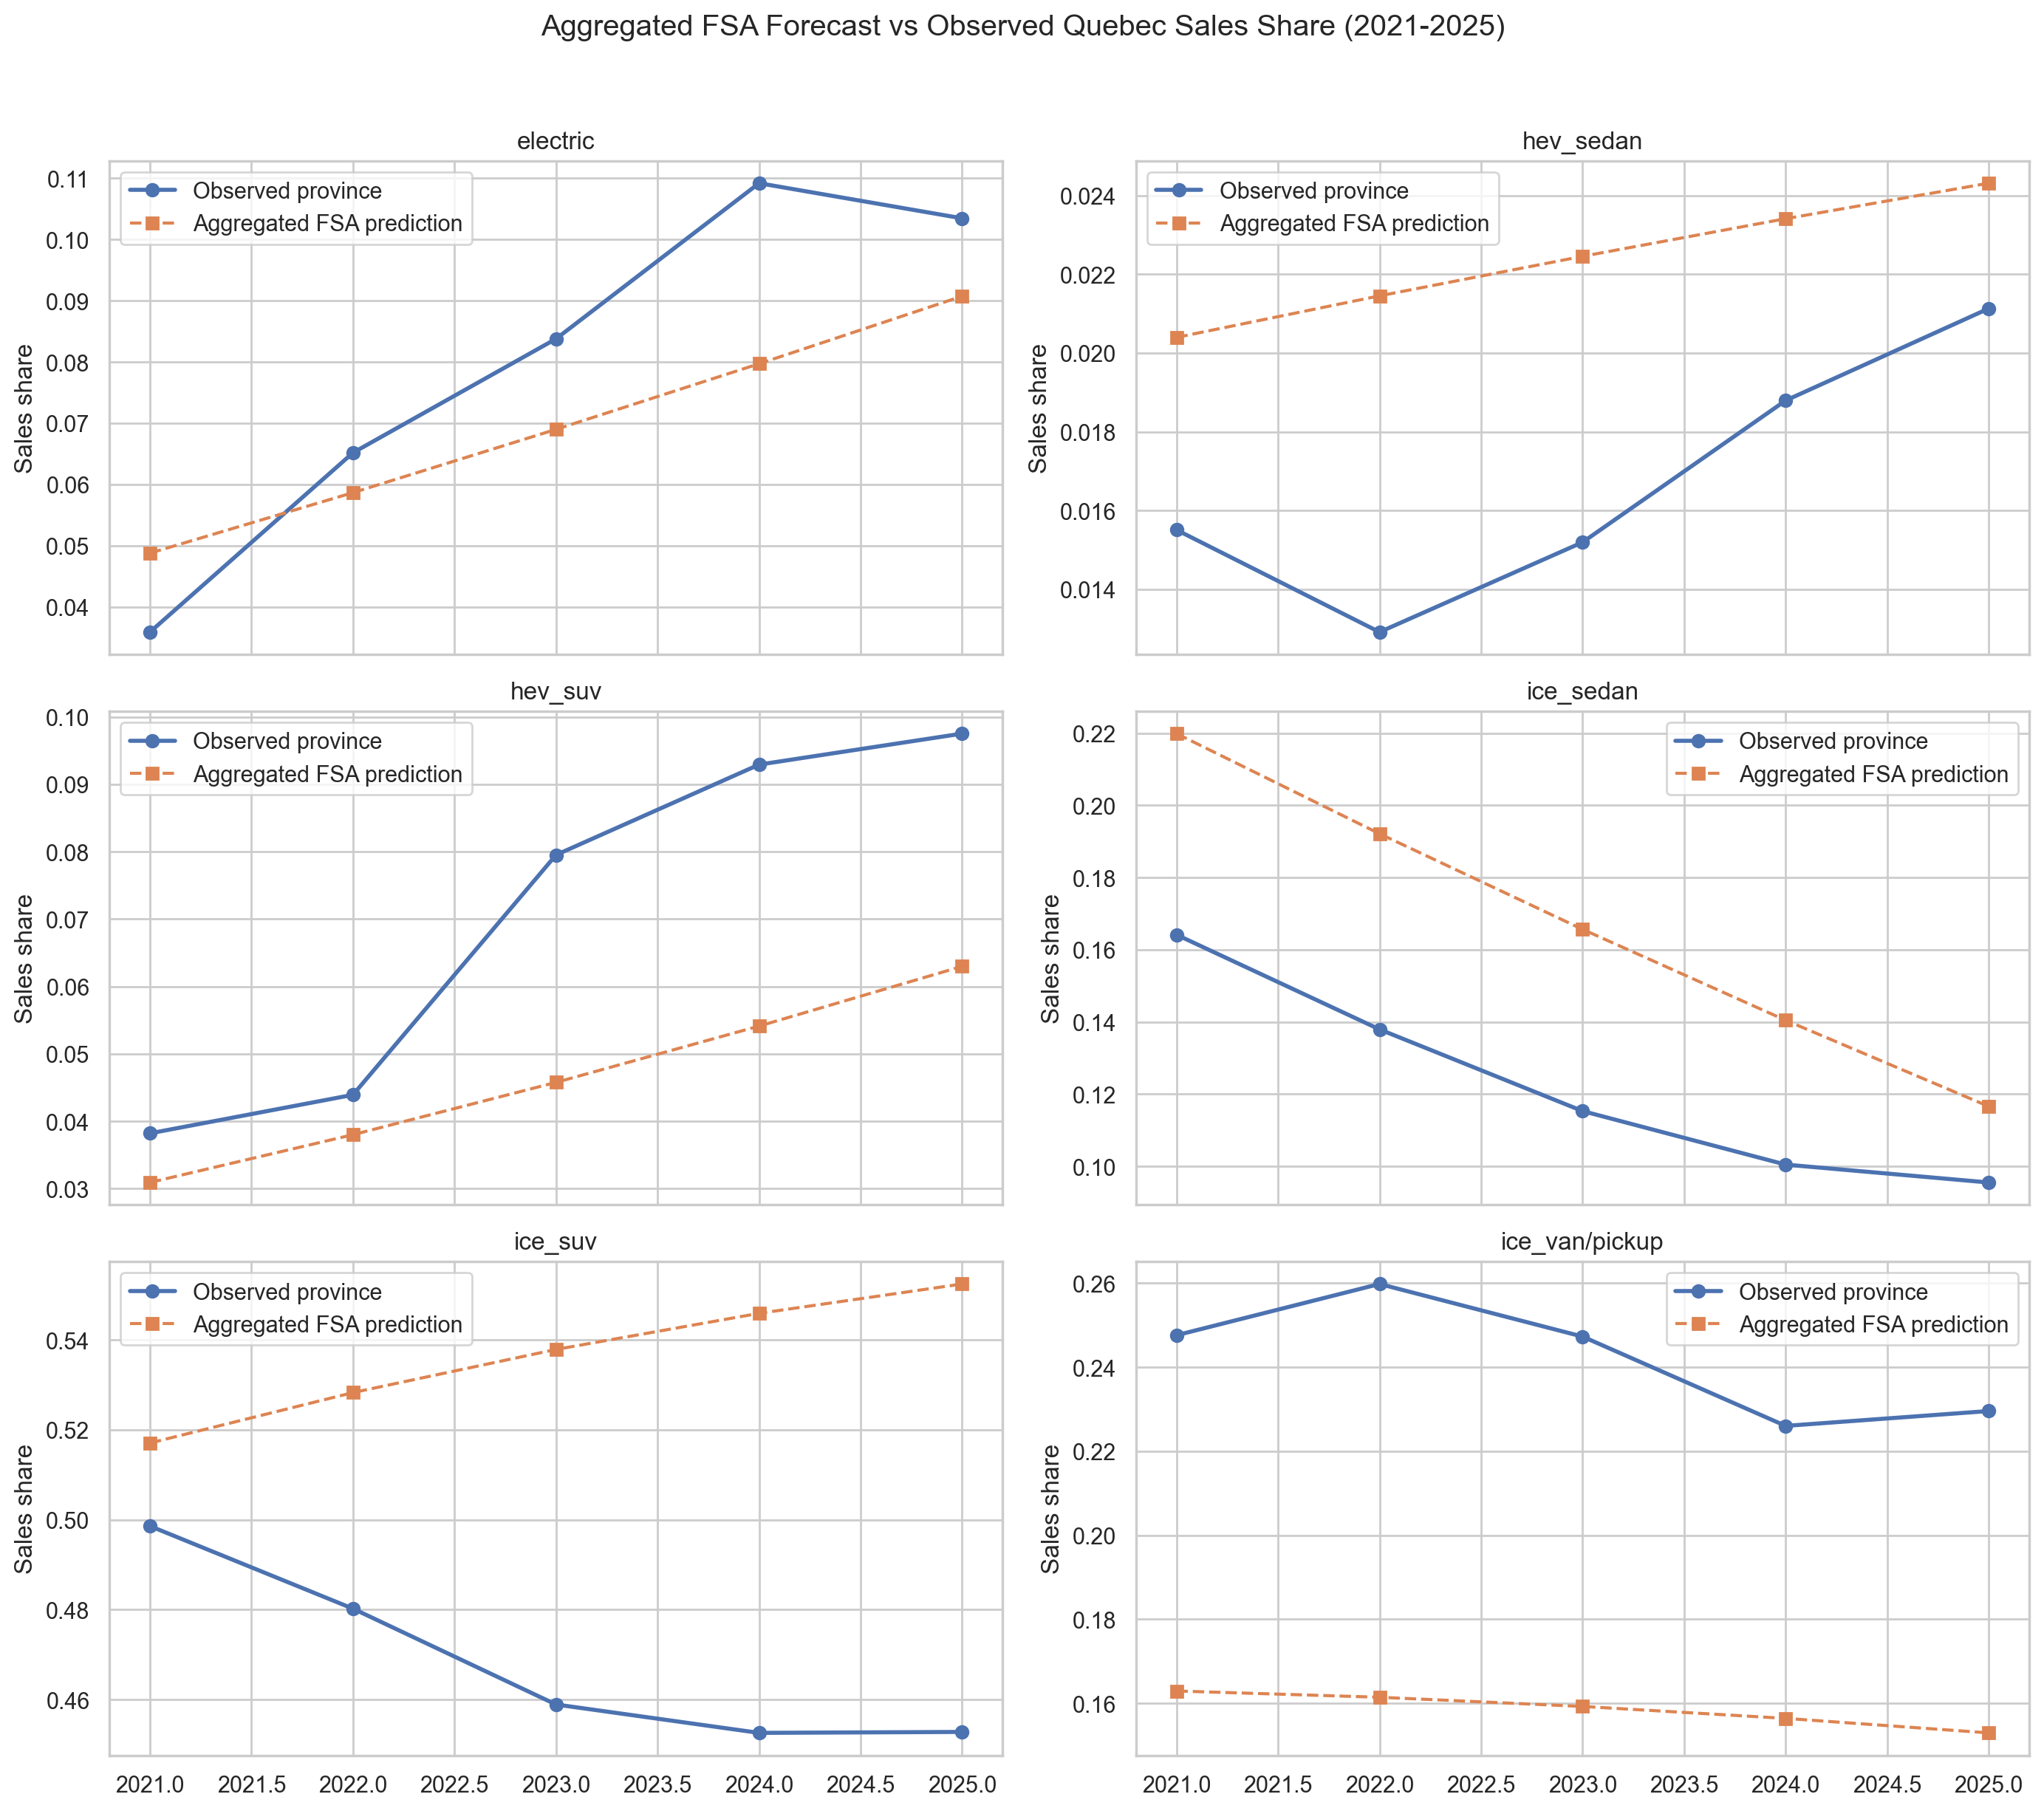

In [12]:
print('fsa_aggregate_vs_province_by_type.png')
display(Image(filename=str(FSA_VALIDATION_DIR / 'fsa_aggregate_vs_province_by_type.png')))

## Side-by-Side Takeaways

In [13]:
summary_table = pd.DataFrame([
    {
        'scope': 'Province sales-share model',
        'validation': 'Train through 2020 -> forecast 2021-2025',
        'best_model': 'hybrid_delta',
        'mae': overall.query("validation == 'train_to_2020_forecast_2021_2025' and model == 'hybrid_delta'")['mae'].iloc[0],
        'rmse': overall.query("validation == 'train_to_2020_forecast_2021_2025' and model == 'hybrid_delta'")['rmse'].iloc[0],
    },
    {
        'scope': 'Province sales-share model',
        'validation': 'Rolling one-step 2021-2025',
        'best_model': 'hybrid_delta',
        'mae': overall.query("validation == 'rolling_one_step' and model == 'hybrid_delta'")['mae'].iloc[0],
        'rmse': overall.query("validation == 'rolling_one_step' and model == 'hybrid_delta'")['rmse'].iloc[0],
    },
    {
        'scope': 'FSA aggregate consistency',
        'validation': 'Aggregate FSA forecast vs province truth, 2021-2025',
        'best_model': 'hierarchical FSA model',
        'mae': fsa_overall['mae'].iloc[0],
        'rmse': fsa_overall['rmse'].iloc[0],
    },
])
summary_table

,scope,validation,best_model,mae,rmse
0,Province sales-share model,Train through 2020 -> forecast 2021-2025,hybrid_delta,0.0156,0.0198
1,Province sales-share model,Rolling one-step 2021-2025,hybrid_delta,0.0109,0.0141
2,FSA aggregate consistency,"Aggregate FSA forecast vs province truth, 2021...",hierarchical FSA model,0.0401,0.0513


## Conclusions

### 1. Province-level validation is encouraging

The recalibrated `hybrid_delta` forecast clearly outperforms both the original `share_delta` rule and the naive baseline in the honest `2020 -> 2025` backtest.

### 2. The recalibration matters substantively

Using the observed `2021-2025` behavior suggests that the earlier EV path was too aggressive. The recalibrated 2035 sales-share path lowers the pure EV trajectory and redistributes some growth into other categories, especially `hev_suv`.

### 3. The FSA model is usable, but weaker

The aggregate FSA forecast is still noticeably noisier than the province model. That means the hierarchical shrinkage idea is directionally right, but local composition is still harder to estimate robustly.

### 4. Current recommendation

For province-level scenario work, the **recalibrated hybrid sales-share model** should be the default.

For FSA-level analysis, results are still useful for spatial interpretation, but they should be treated more cautiously than the province-level forecast and ideally accompanied by confidence flags.